In [95]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import torch
from os.path import join
from utils import *

from braket.circuits import Circuit
# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker

In [38]:
# Returns the codewords using unary embedding
def get_codewords_1d(n : int, encoding, periodic):
    
    codewords = []

    if encoding == "unary" or encoding == "antiferromagnetic":
        if encoding == "unary":
            bitstring = 0
        elif encoding == "antiferromagnetic":
            bitstring = 0
            for k in range(n):
                if k % 2 == 0:
                    bitstring += 1 << k

        if periodic:
            for i in range(2 * n):
                codewords.append(bitstring)
                bitstring ^= 1 << (i % n)
        else:
            for i in range(n+1):
                codewords.append(bitstring)

                if i < n:
                    bitstring ^= 1 << i
    
    elif encoding == "one-hot":

        bitstring = 1

        for i in range(n):
            codewords.append(bitstring)


            if i < n - 1:
                bitstring ^= (1 << i)
                bitstring ^= (1 << (i+1))
    return codewords

# def get_codewords_2d(n : int, encoding, periodic):
    
#     codewords_1d = get_codewords_1d(n, encoding, periodic)
#     N = len(codewords_1d)
#     codewords = []

#     for i in range(N):
#         for j in range(N):
#             codewords.append((codewords_1d[j] << n) + codewords_1d[i])
#     return codewords

In [39]:
N = 5
encoding = "unary"
if encoding == "unary" or encoding == "antiferromagnetic":
    n = N - 1
elif encoding == "one-hot":
    n = N

save_dir = join("qw_data", "spatial_search_ionq")

codewords_1d = get_codewords_1d(n, encoding=encoding, periodic=False)

# number of layers in the circuit
nr_layers = 4

In [40]:
# randomly initialize parameters from a normal distribution
params = np.random.normal(0, np.pi, (n, nr_layers, 2))
params = torch.tensor(params, requires_grad=True)

# the kth layer of the circuit ansatz
def layer(params, k):
    # # RZ rotations
    # for i in range(n):
    #     qml.RX(params[i, k, 0], wires=i)
    
    # # XX rotations
    # for i in range(n-1):
    #     qml.IsingXX(params[i, k, 1], wires=[i, i+1])
        
    if k % 2 == 0:
        # RZ rotations
        for i in range(n):
            qml.RZ(params[i, k, 0], wires=i)
            
        # XX rotations
        for i in range(n-1):
            qml.IsingXX(params[i, k, 1], wires=[i, i + 1])

    else:
        # RX rotations
        for i in range(n):
            qml.RX(params[i, k, 0], wires=i)
            
        # ZZ rotations
        for i in range(n-1):
            qml.IsingZZ(params[i, k, 1], wires=[i, i + 1])

In [41]:
dev = qml.device("default.qubit", wires=range(n))
@qml.qnode(dev, interface="torch")
def circuit(params, A):
    n = params.shape[0]

    # repeatedly apply each layer in the circuit
    for j in range(nr_layers):
        layer(params, j)

    # returns the expectation of the input matrix A on the first qubit
    return qml.expval(qml.Hermitian(A, wires=range(n)))

In [42]:
# cost function
def cost_fn(params, M):
    # Put in I - density matrix for uniform superposition
    cost = 1 - circuit(params, M)
    return cost

In [43]:
uniform_superposition = torch.zeros(2 ** n, dtype=torch.complex128)
for i in range(N):
    uniform_superposition[codewords_1d[i]] += 1 / np.sqrt(N)

M = torch.outer(uniform_superposition, uniform_superposition)

In [44]:
# set up optimizer
opt = torch.optim.Adam([params], lr=0.1)

# number of steps in the optimization routine
steps = 300

best_cost = cost_fn(params, M)
best_params = np.zeros(params.shape)

print("Cost after 0 steps is {:.4f}".format(cost_fn(params, M)))
for i in range(steps):
    opt.zero_grad()
    loss = cost_fn(params, M)
    loss.backward()
    opt.step()
    if loss < best_cost:
        best_cost = loss
        best_params = params

    # Keep track of progress every 10 steps
    if i % 10 == 9 or i == steps - 1:
        print(f"Cost after {i+1} steps is {loss:.4f}")


# torch.save(best_params, join(save_dir, f"params_{encoding}_{n}.pt"))

Cost after 0 steps is 0.9177
Cost after 10 steps is 0.2755
Cost after 20 steps is 0.1435
Cost after 30 steps is 0.0822
Cost after 40 steps is 0.0474
Cost after 50 steps is 0.0135
Cost after 60 steps is 0.0027
Cost after 70 steps is 0.0015
Cost after 80 steps is 0.0005
Cost after 90 steps is 0.0001
Cost after 100 steps is 0.0001
Cost after 110 steps is 0.0000
Cost after 120 steps is 0.0000
Cost after 130 steps is 0.0000
Cost after 140 steps is 0.0000
Cost after 150 steps is 0.0000
Cost after 160 steps is 0.0000
Cost after 170 steps is 0.0000
Cost after 180 steps is 0.0000
Cost after 190 steps is -0.0000
Cost after 200 steps is 0.0000
Cost after 210 steps is 0.0000
Cost after 220 steps is 0.0000
Cost after 230 steps is 0.0000
Cost after 240 steps is 0.0000
Cost after 250 steps is -0.0000
Cost after 260 steps is -0.0000
Cost after 270 steps is 0.0000
Cost after 280 steps is -0.0000
Cost after 290 steps is 0.0000
Cost after 300 steps is 0.0000


# Test spatial search on Braket simulator

In [60]:
params = torch.load(join(save_dir, f"params_{encoding}_{n}.pt"))
params = params.detach().numpy()

In [62]:
use_real_machine = False

if use_real_machine:
    device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
else:
    # set up device: Local Simulator
    device = LocalSimulator()

print(f"Using {device.name}")

Using StateVectorSimulator


In [73]:
# circuit for 2D uniform superposition in embedding subspace
# Note that qubit order is reversed for PennyLane!
def uniform_superposition(params):
    n, nr_layers, _ = params.shape
    
    circuit = Circuit()

    for j in range(2):
        for k in range(nr_layers):
            if k % 2 == 0:
                # RZ rotations
                for i in range(n):
                    circuit.rz(j * n + n - i - 1, params[i, k, 0])
                    
                # XX rotations
                for i in range(n-1):
                    circuit.xx(j * n + n - i - 1, j * n + n - i - 2, params[i, k, 1])

            else:
                # RX rotations
                for i in range(n):
                    circuit.rx(j * n + n - i - 1, params[i, k, 0])
                    
                # ZZ rotations
                for i in range(n-1):
                    circuit.zz(j * n + n - i - 1, j * n + n - i - 2, params[i, k, 1])

    return circuit

In [74]:
circuit = uniform_superposition(params)

In [75]:
print(circuit)

T  : |   0    |   1    |    2    |   3    |    4    |    5    |    6    |    7    |    8    |    9    |   10    |   11   |   12    |
                                                                                                                                    
q0 : -Rz(0.35)--------------------XX(3.14)-Rx(1.15)------------ZZ(-0.89)-Rz(0.89)------------XX(-3.14)-Rx(-4.29)----------ZZ(-3.61)-
                                  |                            |                             |                            |         
q1 : -Rz(0.50)----------XX(10.07)-XX(3.14)-Rx(1.32)--ZZ(-0.79)-ZZ(-0.89)-Rz(3.14)--XX(3.14)--XX(-3.14)-Rx(-3.14)-ZZ(4.71)-ZZ(-3.61)-
                        |                            |                             |                             |                  
q2 : -Rz(6.29)-XX(4.76)-XX(10.07)-Rx(1.64)-ZZ(-4.19)-ZZ(-0.79)-Rz(1.91)--XX(-3.50)-XX(3.14)--Rx(-1.57)-ZZ(1.57)--ZZ(4.71)-----------
               |                           |                         

In [76]:
from utils import *

In [90]:
num_shots = 1000
dimension = 2

task = device.run(circuit, shots=num_shots)

result = task.result()
occurrences = get_occurrences(N, result.measurements, num_shots=num_shots, dimension=2, encoding=encoding)
if np.sum(occurrences) > 0:
    dist = occurrences / np.sum(occurrences)


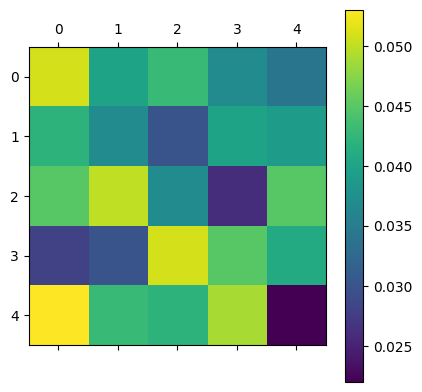

In [92]:
plt.matshow(dist)
plt.colorbar()
plt.show()